In [2]:
import sqlite3
import pandas as pd
import os

# Folder Path where my databases are stored
folder_path = r'C:\Users\jahil\Personal_Projects\Python Projects\job-market-analysis\job-market-extraction\job_data'



# Get all .db files
db_files = [f for f in os.listdir(folder_path) if f.endswith('.db')]

# Check the structure of the files ending with .db
for db in db_files:
    file_path = os.path.join(folder_path, db)
    
    # 1. Connect to the database
    with sqlite3.connect(file_path) as conn:
        # 2. Get the table name (assuming there's only one main table per file)
        tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
        
        if not tables.empty:
            table_name = tables['name'].iloc[0]

            # We use a f-string to put the table_name into the count query
            count_df = pd.read_sql_query(f"SELECT COUNT(*) as total_rows FROM {table_name}", conn)
            row_count = count_df['total_rows'].iloc[0]
            
            # Get the column names using a SQL PRAGMA command
            columns_info = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
            column_names = columns_info['name'].tolist()
            
            print(f"--- File: {db} ---")
            print(f"Table: {table_name}")
            print(f"Rows: {row_count}")
            print(f"Columns: {column_names}\n")
        else:
            print(f"--- File: {db} is empty ---\n")


--- File: jobs_data_2026-03-25.db ---
Table: jobs
Rows: 35
Columns: ['id', 'title', 'company', 'location', 'posted_at', 'description', 'link', 'retrieved_at']

--- File: jobs_data_2026-04-16.db ---
Table: jobs
Rows: 49
Columns: ['id', 'title', 'company', 'location', 'posted_at', 'description', 'link', 'retrieved_at']

--- File: jobs_data_2026-04-16V2.db ---
Table: jobs
Rows: 72
Columns: ['id', 'title', 'company', 'location', 'posted_at', 'description', 'link', 'retrieved_at']

--- File: jobs_data_2026-04-19.db ---
Table: jobs
Rows: 34
Columns: ['id', 'title', 'company', 'location', 'posted_at', 'description', 'link', 'retrieved_at']

--- File: jobs_data_2026-04-20.db ---
Table: jobs
Rows: 0
Columns: ['id', 'title', 'company', 'location', 'posted_at', 'description', 'link', 'retrieved_at']



In [3]:
# Now that I verified they follow the same structure, we can join them all together for futher analysis

# This list will hold each individual dataframe
all_dataframes = []

for db in db_files:
    file_path = os.path.join(folder_path, db)
    
    with sqlite3.connect(file_path) as conn:
        # 1. Get the table name automatically
        table_name_query = "SELECT name FROM sqlite_master WHERE type='table';"
        table_name = pd.read_sql_query(table_name_query, conn)['name'].iloc[0]
        
        # 2. Read the data into a DataFrame
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        
        # 3. Add the extra column with the filename
        df['source_file'] = db
        
        # Add this specific dataframe to our list
        all_dataframes.append(df)

# 4. Join them all together "below each other"
final_df = pd.concat(all_dataframes, axis=0, ignore_index=True)

# Check the results
print(f"Successfully joined {len(db_files)} files.")
print(f"Total rows: {len(final_df)}")
final_df.head()

Successfully joined 5 files.
Total rows: 190


,id,title,company,location,posted_at,description,link,retrieved_at,source_file
0,eyJqb2JfdGl0bGUiOiJTZW5pb3IgRGF0YSBBbmFseXN0IO...,Senior Data Analyst – Capital Markets (Trade &...,IMCS Group,"Toronto, ON, Canada",20 hours ago,Job Title: Senior Data Analyst – Capital Marke...,https://ca.linkedin.com/jobs/view/senior-data-...,2026-03-25 14:53:04,jobs_data_2026-03-25.db
1,eyJqb2JfdGl0bGUiOiJKdW5pb3IgRGF0YSBBbmFseXN0Ii...,Junior Data Analyst,betacalco,"Toronto, ON, Canada",2 days ago,Reports To\n\nHead of Analytics & Strategy\n\n...,https://ca.linkedin.com/jobs/view/junior-data-...,2026-03-25 14:53:04,jobs_data_2026-03-25.db
2,eyJqb2JfdGl0bGUiOiJJbnZlc3RtZW50IERhdGEgQW5hbH...,Investment Data Analyst,Recruit Action inc.,"Toronto, ON, Canada",1 day ago,Data Analyst\n\n(Capital Markets / Investments...,https://ca.linkedin.com/jobs/view/investment-d...,2026-03-25 14:53:04,jobs_data_2026-03-25.db
3,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgaW50ZXJuIi...,Data Analyst intern,Ericsson,"Toronto, ON, Canada",20 hours ago,## Grow with us\n\nData Analyst intern\n\nLoca...,https://jobs.ericsson.com/careers/job/56312177...,2026-03-25 14:53:04,jobs_data_2026-03-25.db
4,eyJqb2JfdGl0bGUiOiJkYXRhYmFzZSBhbmFseXN0IiwiY2...,database analyst,SRCO Professional Corporation,"Richmond Hill, ON, Canada",3 days ago,Education: Bachelor's degree. Work setting: Pr...,https://www.jobbank.gc.ca/jobsearch/jobposting...,2026-03-25 14:53:04,jobs_data_2026-03-25.db


In [4]:
# Remove duplicates based on title and company

# 1. Get the count BEFORE removing duplicates
initial_count = len(final_df)

# 2. Remove the duplicates
# This keeps the first occurrence and removes any subsequent matches
final_df = final_df.drop_duplicates(subset=['title', 'company','location'], keep='first')

# 3. Get the count AFTER removing duplicates
final_count = len(final_df)
duplicates_removed = initial_count - final_count

# 4. Print the results
print(f"Duplicates removed: {duplicates_removed}")
print(f"Total unique rows remaining: {final_count}")


Duplicates removed: 57
Total unique rows remaining: 133


In [5]:
# Since there are columns don't needed for further analysis
# Is Defined the columns we want to keep
cols_to_keep = ['title', 'company', 'location', 'posted_at', 'description','source_file']

# Filter the final dataframe
final_df = final_df[cols_to_keep]

# Print the result to verify
print("\n--- Columns in final analysis ---")
print(final_df.columns.tolist())
print(f"Shape of analysis data: {final_df.shape}")


--- Columns in final analysis ---
['title', 'company', 'location', 'posted_at', 'description', 'source_file']
Shape of analysis data: (133, 6)


In [6]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 0 to 186
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        133 non-null    object
 1   company      133 non-null    object
 2   location     133 non-null    object
 3   posted_at    111 non-null    object
 4   description  125 non-null    object
 5   source_file  133 non-null    object
dtypes: object(6)
memory usage: 7.3+ KB


In [7]:
# This creates a "mask" that is True for every Null description
null_rows = final_df[final_df['description'].isnull()]

# Display the rows
null_rows

,title,company,location,posted_at,description,source_file
27,Operations Data Analyst,Lone Wolf Real Estate Technologies Inc,"Cambridge, ON, Canada",18 hours ago,None,jobs_data_2026-03-25.db
28,"Senior Business Analyst drives complex, multi-...",S.i. Systems,"Toronto, ON, Canada",3 days ago,None,jobs_data_2026-03-25.db
29,Data Analyst - Insights qui transforment nos f...,Co-operators Assurance et services financiers,"Oshawa, ON, Canada",2 days ago,None,jobs_data_2026-03-25.db
30,Lead Systems Analyst,Open Text Corporation,"Waterloo, ON, Canada",3 days ago,None,jobs_data_2026-03-25.db
31,"Remote Data Analyst Jobs – Flexible, Part-Time...",Talyca,Anywhere,3 days ago,None,jobs_data_2026-03-25.db
32,Clinical Data Analyst - Health Informatics (HL...,Houston Skilled Consultancy,"Ottawa, ON, Canada",2 days ago,None,jobs_data_2026-03-25.db
33,Data Analyst​/Developer – Power BI & Microsoft...,NavitasPartners,"Gatineau, Quebec, Canada",18 hours ago,None,jobs_data_2026-03-25.db
34,Data Analyst Intern - Summer,Rocket Innovation Studio,"Windsor, ON, Canada",18 hours ago,None,jobs_data_2026-03-25.db


In [8]:
# Since there are null descriptions, those rows will be delete it.

# Get count before dropping
before_count = len(final_df)

# Drop rows where 'description' is Null
# 'subset' ensures we only look at the description column for nulls
final_df = final_df.dropna(subset=['description'])

# 3. Calculate how many were removed
after_count = len(final_df)
removed_nulls = before_count - after_count

print(f"Removed {removed_nulls} rows with null descriptions.")
print(f"Rows remaining for analysis: {after_count}")

Removed 8 rows with null descriptions.
Rows remaining for analysis: 125


In [9]:
# Lowercaste columns such as title and description for future analysis
final_df['title'] = final_df['title'].str.lower()
final_df['description'] = final_df['description'].str.lower()

<Axes: title={'center': 'Most Requested Skills Canada for Data Analytics'}>

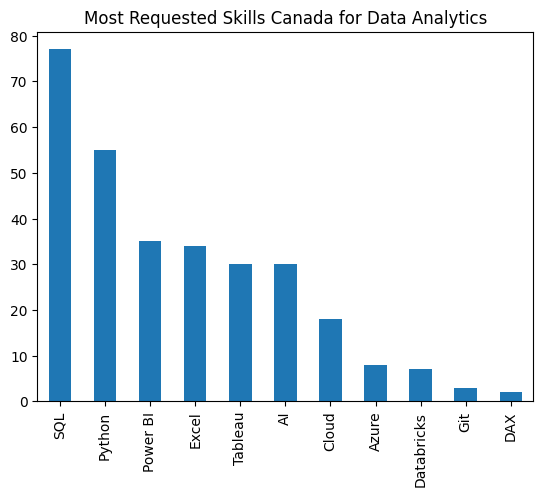

In [10]:
# Define the skills I want to track
skills_to_check = ['SQL', 'Python', 'Power BI', 'Excel', 'Tableau', 'DAX', 'Azure', 'AI', 'Cloud', 'Git','Databricks']

# Create a count for each skill
skill_counts = {}
for skill in skills_to_check:
    # We use case=False to catch "sql" and "SQL"
    count = final_df['description'].str.contains(rf'\b{skill}\b', case=False, na=False).sum()
    skill_counts[skill] = count

# Convert to a Series and Plot
pd.Series(skill_counts).sort_values(ascending=False).plot(kind='bar', title='Most Requested Skills Canada for Data Analytics')

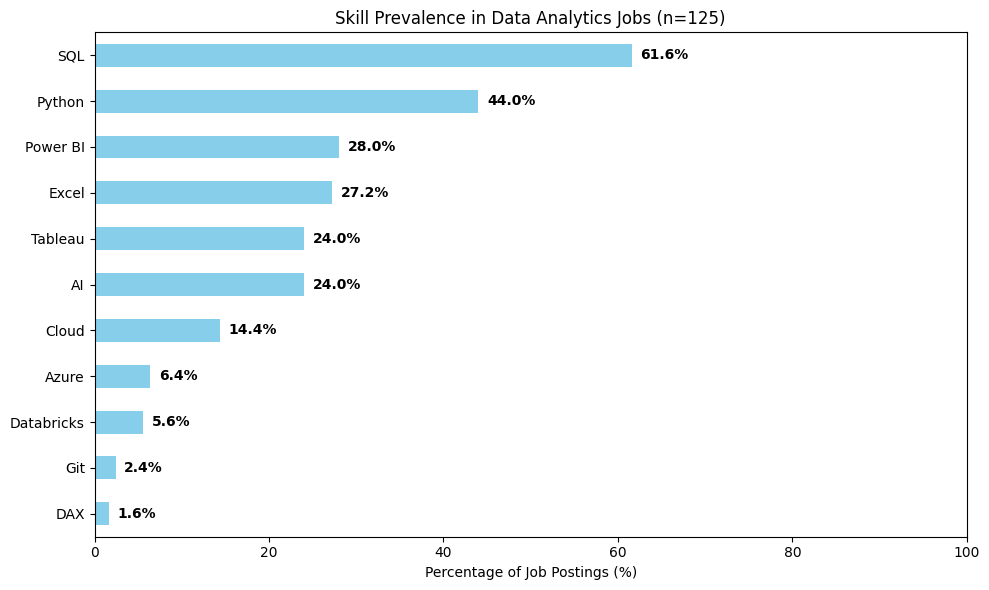

In [11]:
import matplotlib.pyplot as plt

# Get the total number of job descriptions
total_jobs = len(final_df)

# Convert to Series and calculate percentage of total jobs
skill_series = pd.Series(skill_counts).sort_values(ascending=True) # Ascending for horizontal bar
skill_percentages = (skill_series / total_jobs) * 100

# Plot
plt.figure(figsize=(10, 6))
ax = skill_percentages.plot(kind='barh', color='skyblue')

# Add percentage labels to the end of the bars
for i, v in enumerate(skill_percentages):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.title(f'Skill Prevalence in Data Analytics Jobs (n={total_jobs})')
plt.xlabel('Percentage of Job Postings (%)')
plt.xlim(0, 100) # Keep scale to 100% for context
plt.tight_layout()
plt.show()

# Job title cleaning:

In [12]:
# Job Title Exploration
final_df['title'].unique()


array(['senior data analyst – capital markets (trade & transactions)',
       'junior data analyst', 'investment data analyst',
       'data analyst intern', 'database analyst',
       'data analyst or cloud developer|',
       'senior data analyst and reporting - strong power bi experience building and maintaining dashboards, including cost/benefit or financial reporting   101157-',
       'intern - bi/data analyst',
       'digital content & data analyst — ecommerce',
       'sap analytics specialist',
       'senior data analyst and python developer for innovative solutions',
       'senior data analyst - fintech (m/f/d)',
       'data analyst / data scientist',
       'data analyst, collections operations & kpis',
       'liquidity & regulatory reporting analyst — data & sql',
       'sr. business data analyst to collaborate between technical and business teams, guaranteeing data quality, security, and privacy throughout the data deliver',
       'intern – bi/data analyst',
       

In [13]:
# Function to Clean Job Titles

def clean_job_titles(title):
    # 1. Handle missing values
    if not isinstance(title, str): 
        return "Unknown"
    
    # 2. Convert to lowercase for consistent matching
    t = title.lower().strip()
    
    # 3. Check for Seniority first (most specific)
    if any(word in t for word in ['sr.', 'senior', 'sr ', 'lead', 'principal']):
        return 'Senior Data Analyst'
    
    # 4. Check for Junior/Entry
    elif any(word in t for word in ['jr.', 'junior', 'jr ', 'entry', 'intern', 'co-op', 'student']):
        return 'Junior/Entry Analyst'
    
    # 5. Check for Manager Level
    elif any(word in t for word in ['manager.', 'director', 'head of ', 'vp']):
        return 'Manager Data Analyst'   
    
    # 6. Check for single name 'Data Analyst
    elif any(word in t for word in ['data analyst']):
        return 'Data Analyst'   
        
    # 6. Fallback
    return 'Pending'

# Apply it and overwrite the column
final_df['standard_title'] = final_df['title'].apply(clean_job_titles)

# QUICK CHECK: See the counts before plotting
print(final_df['standard_title'].value_counts())

standard_title
Data Analyst            73
Senior Data Analyst     31
Junior/Entry Analyst    12
Pending                  8
Manager Data Analyst     1
Name: count, dtype: int64


In [14]:
# For those that I couldn't assign a managment, senior or junior level, I want to explore what is happening with these job titles
job_title_pending=final_df['standard_title']=='Pending'
final_df[job_title_pending]['title']

4                                      database analyst
9                              sap analytics specialist
14    liquidity & regulatory reporting analyst — dat...
23    business analyst in data analytics healthcare ...
25                                       a&i analyst ii
39                         ehs data and systems analyst
52                                          data analys
63                                         data analysr
Name: title, dtype: object

In [15]:
# !pip install thefuzz

In [16]:
# I identified in the previous output that there are a few titles with mispelling
# For those I will standarize using the fuzz library

from thefuzz import process

# 1. My 'Source of Truth' (The job titles correct)
correct_names = [
    "Data Analyst",
    'Business Analyst',
    "Senior Data Analyst", 
    "Junior/Entry Analyst", 
    "Manager Data Analys"
]

# 2. The messy input (What we actually received)
messy_data = final_df[job_title_pending]['title']

print("--- Automated Cleaning Results ---")

# Shows the possible replace using thefuzz
for entry in messy_data:
    # We find the best match for each messy entry
    match, score = process.extractOne(entry, correct_names)
    
    # We can set a 'Logic Gate': only accept if confidence is > 80%
    if score >= 90:
        print(f"Original: {entry: <22} -> Standardized: {match} ({score}%)")
    else:
        print(f"Original: {entry: <22} -> No confident match found.")

--- Automated Cleaning Results ---
Original: database analyst       -> No confident match found.
Original: sap analytics specialist -> No confident match found.
Original: liquidity & regulatory reporting analyst — data & sql -> No confident match found.
Original: business analyst in data analytics healthcare organizations -> Standardized: Business Analyst (90%)
Original: a&i analyst ii         -> No confident match found.
Original: ehs data and systems analyst -> No confident match found.
Original: data analys            -> Standardized: Data Analyst (96%)
Original: data analysr           -> Standardized: Data Analyst (92%)


In [17]:
# --- Function that applies the replacement ---
def standardize_titles(entry, correct_names, threshold=90):
    match, score = process.extractOne(entry, correct_names)
    if score >= threshold:
        return match
    return "Related to Data Analytics"

# Only apply to rows where standard_title is pending
mask = final_df['standard_title'] == 'Pending'

final_df.loc[mask, 'standard_title'] = final_df.loc[mask, 'title'].apply(
    lambda x: standardize_titles(x, correct_names)
)

print(final_df['standard_title'].value_counts())


standard_title
Data Analyst                 75
Senior Data Analyst          31
Junior/Entry Analyst         12
Related to Data Analytics     5
Manager Data Analyst          1
Business Analyst              1
Name: count, dtype: int64


# Skills by job title

In [18]:
# Identify skills for the specific job title
# We create temporary boolean columns for easier grouping

for skill in skills_to_check:
    final_df[f'{skill}_req'] = final_df['description'].str.contains(rf'\b{skill}\b', case=False, na=False)

# 1. Define the skill columns
skill_columns = [f'{skill}_req' for skill in skills_to_check]

# 2. FIX: Group by the COLUMN name 'seniority', not a specific job title
skills_by_seniority = final_df.groupby('standard_title')[skill_columns].sum()

# 3. Clean up the column names
skills_by_seniority.columns = skills_to_check

# 4. Display
print(skills_by_seniority)


                           SQL  Python  Power BI  Excel  Tableau  DAX  Azure  \
standard_title                                                                 
Business Analyst             1       0         0      0        0    0      0   
Data Analyst                39      28        18     18       10    2      5   
Junior/Entry Analyst        10       9         8      7        4    0      2   
Manager Data Analyst         1       1         0      0        1    0      0   
Related to Data Analytics    3       2         1      2        1    0      0   
Senior Data Analyst         23      15         8      7       14    0      1   

                           AI  Cloud  Git  Databricks  
standard_title                                         
Business Analyst            0      0    0           0  
Data Analyst               22      9    1           2  
Junior/Entry Analyst        1      3    2           1  
Manager Data Analyst        0      0    0           0  
Related to Data Analyti

In [19]:
# %pip install wordcloud matplotlib

# Description Column Exploration:

In [20]:
table_years_exp=final_df.copy()
table_years_exp.drop(columns=['title','location', 'posted_at', 'source_file','SQL_req',
                                                 'Python_req','Power BI_req', 'Excel_req', 'Tableau_req', 
                                                 'DAX_req', 'Azure_req','AI_req', 'Cloud_req', 'Git_req', 
                                                 'Databricks_req'], inplace=True)
table_years_exp

,company,description,standard_title
0,IMCS Group,job title: senior data analyst – capital marke...,Senior Data Analyst
1,betacalco,reports to\n\nhead of analytics & strategy\n\n...,Junior/Entry Analyst
2,Recruit Action inc.,data analyst\n\n(capital markets / investments...,Data Analyst
3,Ericsson,## grow with us\n\ndata analyst intern\n\nloca...,Junior/Entry Analyst
4,SRCO Professional Corporation,education: bachelor's degree. work setting: pr...,Related to Data Analytics
...,...,...,...
179,AIP Connect,a boutique heor consulting firm is seeking a d...,Data Analyst
180,Motive,elevate marketing strategies as a senior marke...,Senior Data Analyst
181,Slice,a technology and service company based in cana...,Data Analyst
182,Fanatics Betting & Gaming,about us\n \n \n fanatics is building a ...,Senior Data Analyst


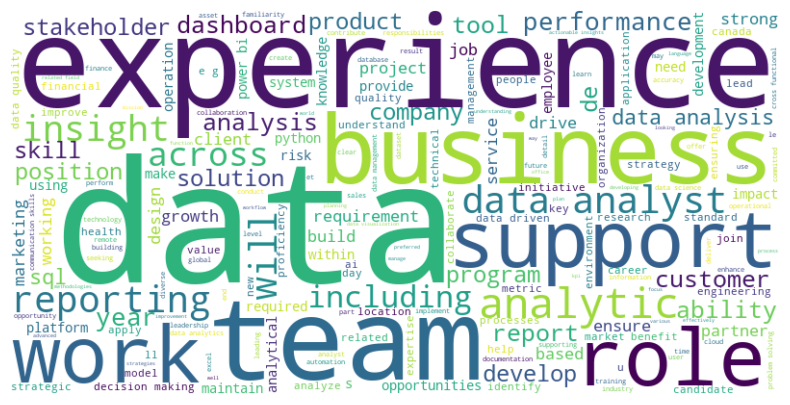

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all descriptions into one giant string
text = " ".join(desc for desc in table_years_exp.description)

# Generate the cloud (ignoring common words like 'the', 'and', etc.)
wordcloud = WordCloud(background_color="white", width=800, height=400).generate(text)

# Display it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [22]:
import re

# I wanna count how many instances of the word 'experience' or 'exp' there are for each job description 
def count_experience_instances(text):
    if not isinstance(text, str):
        return 0
    
    text = text.lower()
    # \b ensures we match the whole word 'exp', not 'expensive'
    matches = re.findall(r'\b(?:experience|exp)\b', text)
    return len(matches)

table_years_exp['exp_count'] = table_years_exp['description'].apply(count_experience_instances)
table_years_exp['exp_count']

0       4
1       3
2       4
3       3
4       1
       ..
179     1
180     0
181     1
182    11
186     0
Name: exp_count, Length: 125, dtype: int64

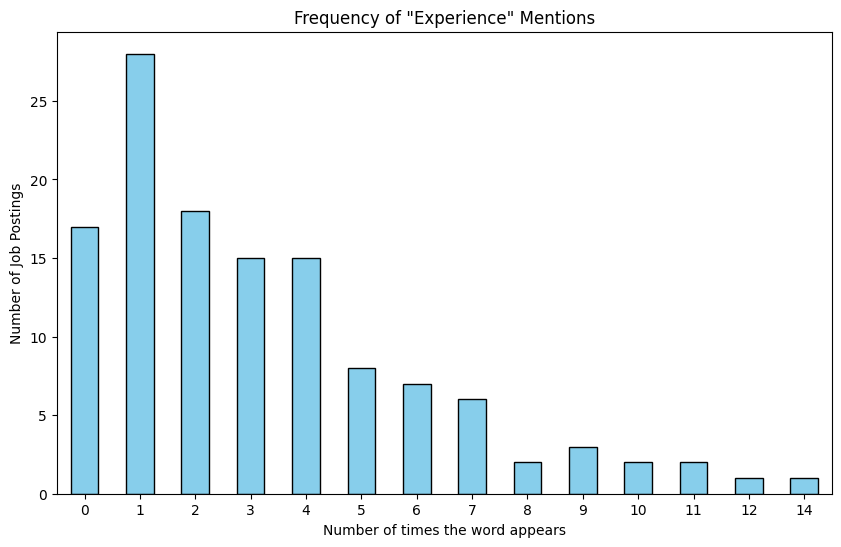

In [23]:
# I want to plot how many 'experiences' instances there are for row
counts = table_years_exp['exp_count'].value_counts().sort_index()

# Plot as a bar chart
counts.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# Add labels for clarity
plt.title('Frequency of "Experience" Mentions')
plt.xlabel('Number of times the word appears')
plt.ylabel('Number of Job Postings')

# 4. Rotate labels if they are crowded (optional)
plt.xticks(rotation=0)

# 5. Save the plot
plt.savefig('experience_bar_chart.png')


# Exploring how behave the rows when the word 'experience' is NOT mentioned

In [24]:
# Create a filter for rows where the count is 0
mask_zero = table_years_exp['exp_count'] == 0

# Show a sample of the 'description' column for those rows
table_years_exp[mask_zero][['standard_title', 'description']]

,standard_title,description
14,Related to Data Analytics,a prominent recruitment agency seeks an experi...
51,Junior/Entry Analyst,job summary job summary: we're seeking a high...
57,Data Analyst,this role involves assisting clients in integr...
78,Data Analyst,about the position the data analyst – platfor...
81,Data Analyst,are you a detail-oriented and analytical indiv...
135,Data Analyst,crowdstrike is a global leader in cybersecurit...
138,Junior/Entry Analyst,about the company deloitte is a leading global...
140,Senior Data Analyst,title: sr. data analyst - risk management & co...
153,Data Analyst,role overview the data analyst will be respons...
156,Data Analyst,elevate data management effectiveness with you...


In [25]:
# This shows exaclty a punctual case
print(table_years_exp['description'].loc[156])

elevate data management effectiveness with your expertise as a master data analyst. collaborate remotely to streamline data processes and support strategic analysis for impactful decision-making.


this role involves establishing data quality metrics and overseeing data integration across multiple legacy systems. you will be tasked with finding actionable insights within complex datasets while creating insightful reports and dashboards for various stakeholders.


key responsibilities
manage data migration, cleansing, and integration initiativesdevelop and implement comprehensive data quality processesanalyze data to identify trends and provide insightscreate and enforce data quality metrics and controlspublish reports and dashboards for stakeholder clarity
requirements
us citizenship with ability to obtain secret clearance5+ years in data analysis, particularly in defense sectorsproficiency in sql, python, and visualization toolsstrong knowledge of erp data migration practicesbachelor’

In [26]:
# Creates a table that I will merge further
# Here the table contains those where the word experience is not mentioned
no_word_experience_mentioned=table_years_exp[mask_zero]
no_word_experience_mentioned.shape

(17, 4)

In [27]:
# Rows where exp_count > 0
experience_mentioned = table_years_exp[table_years_exp['exp_count'] > 0]

# Or using the mask you already have (negating it)
experience_mentioned = table_years_exp[~mask_zero]
experience_mentioned.shape

(108, 4)

## Exploring how behave the rows when the word 'experience' is mentioned one or more than once

In [28]:
# Create a filter for rows where the count is 1
experience_subset_1 = experience_mentioned[experience_mentioned['exp_count'] == 1]

# Show a sample of the 'description' column when the word experience is mentioned once
experience_subset_1[['standard_title', 'description']].head(3)

,standard_title,description
4,Related to Data Analytics,education: bachelor's degree. work setting: pr...
10,Senior Data Analyst,elevate your career as a senior data analyst &...
17,Data Analyst,position: data analyst (sas/sql) - hybrid; con...


In [29]:
experience_subset_1.iloc[0]['description']

"education: bachelor's degree. work setting: private sector. tasks: develop and implement a strategic blueprint to follow when deploying databases within their organization. develop and maintain computer databases. enact measures to make sure unauthorized users cannot access the data. test data models and database management systems. design and develop database. operate database management systems to analyze data. research and document data requirements, data collection and administration policy, and data access rules. develop policies and procedures for network access and usage and for the backup and recovery of data. write scripts related to stored procedures and triggers. analyze data and prepare reports. computer and technology knowledge: word processing software. image editing software. programming software. database software. software development. data analysis software. ms office. ms windows. spreadsheet. electronic mail. security and safety: criminal record check. work conditio

In [30]:
# Create a filter for rows where the count is 2
experience_subset_2 = experience_mentioned[experience_mentioned['exp_count'] == 2]
experience_subset_2[['standard_title', 'description']].head(3)

,standard_title,description
7,Junior/Entry Analyst,"are you curious, analytical, and eager to appl..."
8,Data Analyst,a recruitment agency is seeking a digital cont...
16,Junior/Entry Analyst,kensington delivers the world’s most personal ...


In [31]:
# Shows an example of the first row that contains two times the word experience
experience_subset_2.iloc[0]['description']

"are you curious, analytical, and eager to apply your skills to real business challenges? join us for a hands-on internship where data meets unforgettable travel experiences.\n\nwhat you'll do\n\nas a bi/data analyst intern, you'll work with our analytics team to uncover insights that drive business growth and optimize client experiences in the luxury travel space. you'll dive into data using tools like sql, power bi, and excel, and get the chance to contribute directly to dashboards, kpis, and decision-making.\n\nyou will:\n• extract and manipulate data using sql and/or python\n• build visualizations and interactive dashboards in power bi desktop and microsoft fabric\n• support performance tracking by developing kpis and report automation\n• conduct ad hoc analyses to answer business questions and uncover trends\n• translate business needs into analytical solutions through critical thinking and hypothesis testing\n• learn how to work with stakeholders across departments to understand 

There are not a clear pattern in the job description when the years of experience are described. 
A column can mention the word more than once since the word experience is linked to the companny experience
That is why I can not assume that just extracting a pattern +X years I will get the real one experience 
My approach for this is to extract the surrounding words and pass it through a transformer

In [32]:
# This function extracts 6 surrounding words from the word 'experience'
# This aim to narrow down the text and just focus on those phrases where the word experience is mentioned specifaclly
def extract_all_neighborhoods(text, window=6):
    if not isinstance(text, str):
        return []
    
    text = ' '.join(text.lower().split())
    
    # Split into words and find the index of 'experience'/'exp'
    words = text.split()
    results = []
    
    for i, word in enumerate(words):
        if re.fullmatch(r'exp(?:erience)?', word.strip('.,;:•')):
            # Grab `window` words before and after
            start = max(0, i - window)
            end = min(len(words), i + window + 1)
            snippet = ' '.join(words[start:end])
            results.append(snippet)
    
    return results

In [33]:
# Table experience_mentioned: A new column is created to store the list of the words that surround the word experience
experience_mentioned['experience_instances'] = experience_mentioned['description'].apply(extract_all_neighborhoods)
experience_mentioned.shape

C:\Users\jahil\AppData\Local\Temp\ipykernel_3032\685030233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experience_mentioned['experience_instances'] = experience_mentioned['description'].apply(extract_all_neighborhoods)


(108, 5)

In [36]:
#   Check which chunks from the column 'experience_instances'  mention explicitly a number
# If the column does not mention any number, it means, there are not years of experience specidied 

number_words = [
    'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
    'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen', 'eighteen', 'nineteen',
    'twenty'
]

def count_numbers(chunks):
    count = 0
    for chunk in chunks:
        # Count digits
        digits = re.findall(r'\d+', chunk)
        count += len(digits)
        
        # Count number words
        for word in number_words:
            # use \b to match whole words only
            matches = re.findall(rf'\b{word}\b', chunk.lower())
            count += len(matches)
    
    return count

experience_mentioned['number_count'] = experience_mentioned['experience_instances'].apply(count_numbers)

C:\Users\jahil\AppData\Local\Temp\ipykernel_3032\1739593719.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experience_mentioned['number_count'] = experience_mentioned['experience_instances'].apply(count_numbers)


In [37]:
# Jobs where experience is mentioned AND a specific number of years is stated (number_count > 0)
years_and_exp_mentioned = experience_mentioned[experience_mentioned['number_count'] > 0]

# Jobs where experience is mentioned BUT no specific number of years is given (number_count == 0)
not_years_mentioned = experience_mentioned[experience_mentioned['number_count'] == 0]

print(f"Years and exp mentioned: {years_and_exp_mentioned.shape}")
print(f"Not years mentioned:     {not_years_mentioned.shape}")

Years and exp mentioned: (73, 6)
Not years mentioned:     (35, 6)


# Since is not information structured, I will use transformers to analyze the rest of the column

In [ ]:
# !pip install transformers torch requests certifi --upgrade

In [ ]:
# !pip install torch

In [85]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# List of number words
number_words = [
    'zero','one', 'two', 'three', 'four', 'five', 
    'six', 'seven', 'eight', 'nine', 'ten',
    'eleven', 'twelve', 'fifteen', 'twenty'
]

results_list = []


# Loop where the column pass through the transformer and clasify if the chunk is a job requirement
for idx, row in years_and_exp_mentioned.iterrows():
    chunks = row['experience_instances']
    
    row_results = []
    for chunk in chunks:
        
        # Check for digits
        has_digit = bool(re.search(r'\d+', chunk))
        
        # Check for number words
        has_number_word = any(word in chunk.lower() for word in number_words)
        
        if has_digit or has_number_word:
            result = classifier(
                chunk,
                candidate_labels=['years of experience required from the candidate']
            )
            
            label = result['labels'][0]
            confidence = round(result['scores'][0], 2)
            
            if label == 'years of experience required from the candidate' and confidence >= 0.50:
                row_results.append({
                    'text': chunk,
                    'confidence': confidence
                })
    
    results_list.append(row_results)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 13256.09it/s]


In [86]:
years_and_exp_mentioned['job_requirements'] = results_list

C:\Users\jahil\AppData\Local\Temp\ipykernel_3032\3843899249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  years_and_exp_mentioned['job_requirements'] = results_list


In [87]:
years_and_exp_mentioned['job_requirements'] 

0      [{'text': 'required skills • 7–10 years of exp...
1      [{'text': 'field. • 0–3 years of professional ...
2      [{'text': '• 2 to 4 years of experience in dat...
4                                                     []
5      [{'text': 'requirements: • 5+ years of design ...
                             ...                        
172    [{'text': 'should have 5+ years of analytics e...
175    [{'text': 'technology [level 3] min years of e...
176    [{'text': 'minimum of 2 to 3 years’ experience...
179    [{'text': 'have at least 2 years of experience...
182    [{'text': 'data pipelines, documentation, and ...
Name: job_requirements, Length: 73, dtype: object

In [88]:
# Filter out list classified as job requirement. 
# An empty list means the transformer did not find in the description years of experience
filled = years_and_exp_mentioned[years_and_exp_mentioned['job_requirements'].apply(lambda x: len(x) > 0)]

#Prints how many results the algortihm found to classify them
print(filled['job_requirements'].count())

68


In [108]:
print(filled['job_requirements'].iloc[1])

[{'text': 'field. • 0–3 years of professional experience in data analysis or a related', 'confidence': 0.88}]


In [90]:
# I want to filter those rows which the algorith did not find years of experience
not_filled = years_and_exp_mentioned[years_and_exp_mentioned['job_requirements'].apply(lambda x: len(x) == 0)]
print(not_filled['job_requirements'].count())
print(not_filled[['experience_instances','job_requirements']].iloc[0])

5
experience_instances    [team player. adaptability. accountability. qu...
job_requirements                                                       []
Name: 4, dtype: object


In [101]:
for chunk in not_filled['experience_instances'].iloc[1]:
    print(chunk)
    print('---')

retail platform. successful candidates should have experience in ecommerce and strong excel skills.
---
to $25 per hour, based on experience and other factors. #j-18808-ljbffr
---


In [95]:
# I am using the following lines of code to test the output with single inputs
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Test with your exact example
test_chunk = "experience 7 months"

result = classifier(
    test_chunk,
    candidate_labels=["years of experience required from the candidate", "other"]
)

print(f"Text: {test_chunk}")
print(f"Label: {result['labels'][0]}")
print(f"Confidence: {result['scores'][0]:.2f}")

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 13491.65it/s]


Text: experience 7 months
Label: other
Confidence: 0.97


In [103]:
print(f"Original:              {len(table_years_exp):>6}")
print(f"No experience mentioned, label:{len(no_word_experience_mentioned):>6}")
print(f"Experience mentioned:    {len(experience_mentioned):>6}")


print('-'*10)
print(f"Experience mentioned:    {len(experience_mentioned):>6}")
print(f"Years mentioned:    {len(years_and_exp_mentioned):>6}")
print(f"Years not mentioned:    {len(not_years_mentioned):>6}")
print('-'*10)
print(f"Years mentioned:    {len(years_and_exp_mentioned):>6}")
print(f"IS 'job requirement':    {len(filled):>6}")
print(f"NOT 'job requirement':    {len(not_filled):>6}")



Original:                 125
No experience mentioned, label:    17
Experience mentioned:       108
----------
Experience mentioned:       108
Years mentioned:        73
Years not mentioned:        35
----------
Years mentioned:        73
IS 'job requirement':        68
NOT 'job requirement':         5


# Functions I want to apply to extract years of experience

In [ ]:
# Function extracts patterns identified
def extract_years_of_experience(results):
    for item in results:
        text = item['text']
        pattern = r'(\d+\s*[+]|\d+\s*[-–]\s*\d+|\d+)\s*(?:years?|yrs?)'
        matches = re.findall(pattern, text.lower())
        if matches:
            return matches[0]  # return first match found as a plain string
    return None  # no match found

In [ ]:
filled['years_extracted'] = filled['job_requirements'].apply(extract_years_of_experience)
filled[['standard_title','years_extracted']]

C:\Users\jahil\AppData\Local\Temp\ipykernel_3032\1448824581.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filled['years_extracted'] = filled['job_requirements'].apply(extract_years_of_experience)


,standard_title,years_extracted
0,Senior Data Analyst,7–10
1,Junior/Entry Analyst,0–3
2,Data Analyst,4
5,Data Analyst,5+
9,Related to Data Analytics,6
...,...,...
172,Data Analyst,5+
175,Data Analyst,15+
176,Data Analyst,3
179,Data Analyst,2


In [126]:
def extract_minimum_years(value):
    if pd.isna(value):
        return None
    
    # Match range like 1-3 or 0–3
    range_match = re.search(r'(\d+)\s*[-–]\s*\d+', value)
    if range_match:
        return int(range_match.group(1))
    
    # Match 5+ or just 5
    single_match = re.search(r'(\d+)', value)
    if single_match:
        return int(single_match.group(1))
    
    return None

filled['minimum_required'] = filled['years_extracted'].apply(extract_minimum_years)

In [128]:
filled[['standard_title','minimum_required']]

,standard_title,minimum_required
0,Senior Data Analyst,7
1,Junior/Entry Analyst,0
2,Data Analyst,4
5,Data Analyst,5
9,Related to Data Analytics,6
...,...,...
172,Data Analyst,5
175,Data Analyst,15
176,Data Analyst,3
179,Data Analyst,2


In [129]:
filled['minimum_required'].describe()
# gives you mean, min, max, std

count    65.000000
mean      4.553846
std       2.772808
min       0.000000
25%       3.000000
50%       5.000000
75%       5.000000
max      15.000000
Name: minimum_required, dtype: float64

In [139]:
filled.groupby('standard_title')['minimum_required'].describe()

,count,mean,std,min,25%,50%,75%,max
standard_title,,,,,,,,
Business Analyst,1.0,3.000000,NaN,3.0,3.00,3.0,3.00,3.0
Data Analyst,42.0,4.214286,2.580752,1.0,2.00,4.0,5.00,15.0
Junior/Entry Analyst,2.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
Manager Data Analyst,1.0,5.000000,NaN,5.0,5.00,5.0,5.00,5.0
Related to Data Analytics,1.0,6.000000,NaN,6.0,6.00,6.0,6.00,6.0
Senior Data Analyst,18.0,5.833333,2.854305,2.0,4.25,5.0,6.75,11.0


Since my job titles like 'business analyst', 'Junior/Entry Analysr', 'Manager Data Analyst' and Related to Data Analytics are not significant, i wontr be analyzing each group
For this case I will be analyzing the information as a whole

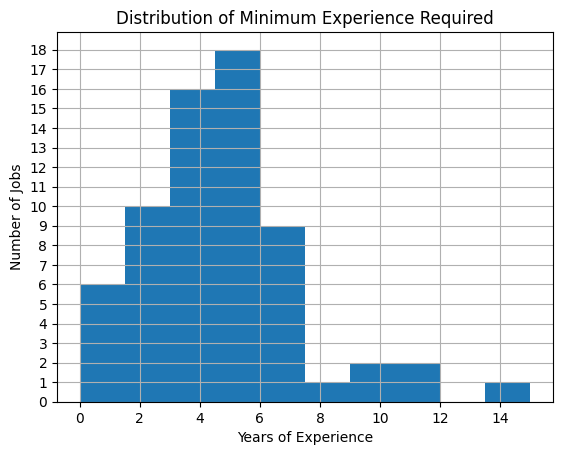

In [140]:
import matplotlib.pyplot as plt
filled['minimum_required'].hist(bins=10)
plt.xlabel('Years of Experience')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Minimum Experience Required')
plt.yticks(range(0, int(filled['minimum_required'].value_counts().max()) + 1))
plt.show()

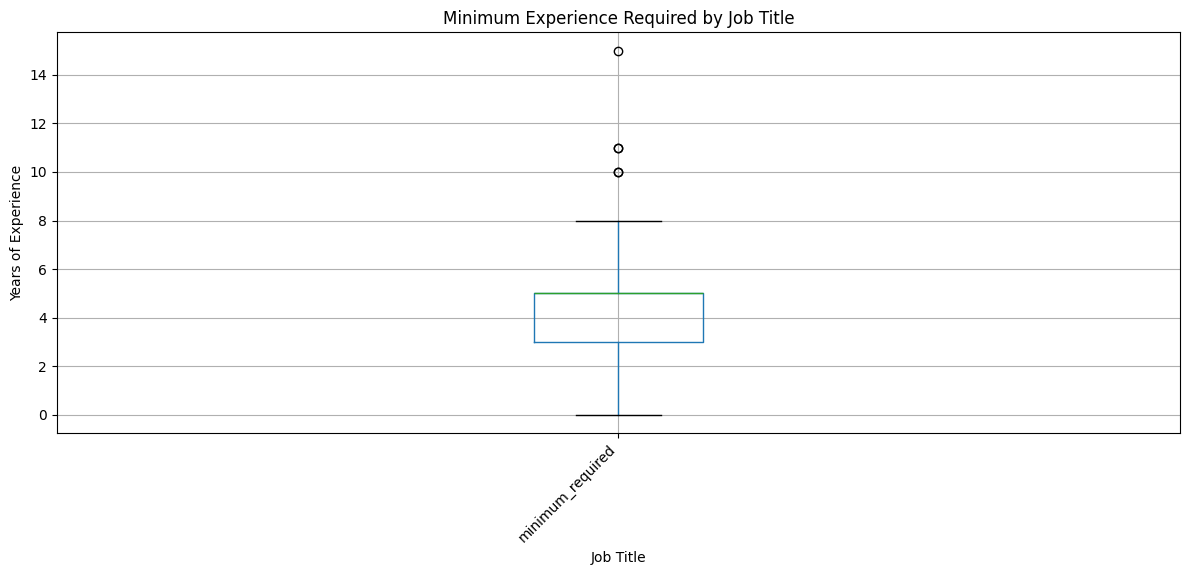

In [142]:
filled.boxplot(column='minimum_required', figsize=(12, 6))
plt.xlabel('Job Title')
plt.ylabel('Years of Experience')
plt.title('Minimum Experience Required by Job Title')
plt.suptitle('')  # removes the default pandas subtitle
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [155]:
# Exploring the outliers
outliers=filled[filled['minimum_required']>=10]
outliers[['standard_title','description','minimum_required']]

,standard_title,description,minimum_required
15,Senior Data Analyst,our valued client is looking for a sr. busines...,10
37,Senior Data Analyst,about us\n\nfanatics is building a leading glo...,11
169,Senior Data Analyst,"at valuemomentum’s technology center, we are a...",10
175,Data Analyst,overviewpipecare group is currently looking fo...,15
182,Senior Data Analyst,about us\n \n \n fanatics is building a ...,11


In [159]:
print(outliers.iloc[3]['description'])

overviewpipecare group is currently looking for emat data analyst level 3 to join our team in calgary, canada. by providing technology and service focused solutions to the international arena of the oil and gas industry, pipecare group has been helping customers ensure the integrity of their pipeline and facility assets for over 20 years. pipecare is seeking experienced emat data analyst [level 3] to support our continued growth. the selected candidate will be working with project execution teams to ensure timely and accurate reporting of in-line inspection results, with a focus on custom-tailored reporting solutions to satisfy customer needs. this includes reviewing customer requirement specifications, processing in-line inspection data, analyzing and identifying pipeline features and anomalies within processed data sets, applying industry accepted anomaly assessment criteria, ensuring the quality and accuracy of the final results, and compiling inspection results into concise, compre

# The outliers wont be delete it because is actually a real experience required. It was not a wrong classification.

In [160]:
(filled['minimum_required'] >= 3).mean() * 100

np.float64(75.38461538461539)